In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [22]:
df = pd.read_csv("cleaned_data/tbills.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [23]:
df.shape

(3053, 1)

In [24]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3053 entries, 2015-01-01 to 2026-04-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   3053 non-null   float64
dtypes: float64(1)
memory usage: 47.7 KB


In [25]:
df.head()

,price
date,
2015-01-01,11.95
2015-01-02,11.95
2015-01-04,12.20
2015-01-05,11.95
2015-01-06,12.20


In [26]:
df.tail()

,price
date,
2026-04-24,23.285
2026-04-27,23.257
2026-04-28,23.765
2026-04-29,23.642
2026-04-30,23.671


In [27]:
#print null count
print(df.isnull().sum())

price    0
dtype: int64


In [28]:
# 1. Calculate Daily Return (This is your daily Rf)
df['daily_return'] = df['price'].pct_change()

In [29]:
# We shift the returns so today's row contains YESTERDAY'S return
df['return_lag1'] = df['daily_return'].shift(1)
df['return_lag2'] = df['daily_return'].shift(2)
df['return_lag3'] = df['daily_return'].shift(3)

In [30]:
# 2. Calculate Annualized Yield (Assuming 252 trading days in a year)
df['annual_yield'] = df['daily_return'] * 252 

In [31]:
# 3. Calculate 20-Day Rolling Volatility
df['volatility_20'] = df['daily_return'].rolling(window=20).std()

In [32]:
# 4. Create the Target Label (Optional, but good for your classifiers)
df['label'] = (df['daily_return'] > df['volatility_20']).astype(int)

In [33]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [34]:
df.drop(columns=['price', 'daily_return', 'volatility_20'], inplace=True)

In [35]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3033 entries, 2015-01-26 to 2026-04-30
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   return_lag1   3033 non-null   float64
 1   return_lag2   3033 non-null   float64
 2   return_lag3   3033 non-null   float64
 3   annual_yield  3033 non-null   float64
 4   label         3033 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 142.2 KB


In [36]:
df.head()

,return_lag1,return_lag2,return_lag3,annual_yield,label
date,,,,,
2015-01-26,0.000000,-0.014007,0.014205,-18.065411,0
2015-01-27,-0.071688,0.000000,-0.014007,0.000000,0
2015-01-28,0.000000,-0.071688,0.000000,0.000000,0
2015-01-29,0.000000,0.000000,-0.071688,0.000000,0
2015-01-30,0.000000,0.000000,0.000000,0.000000,0


In [37]:
df.tail()

,return_lag1,return_lag2,return_lag3,annual_yield,label
date,,,,,
2026-04-24,0.000817,-0.003896,0.004991,-0.010822,0
2026-04-27,-0.000043,0.000817,-0.003896,-0.303028,0
2026-04-28,-0.001202,-0.000043,0.000817,5.504407,1
2026-04-29,0.021843,-0.001202,-0.000043,-1.304271,0
2026-04-30,-0.005176,0.021843,-0.001202,0.309111,0


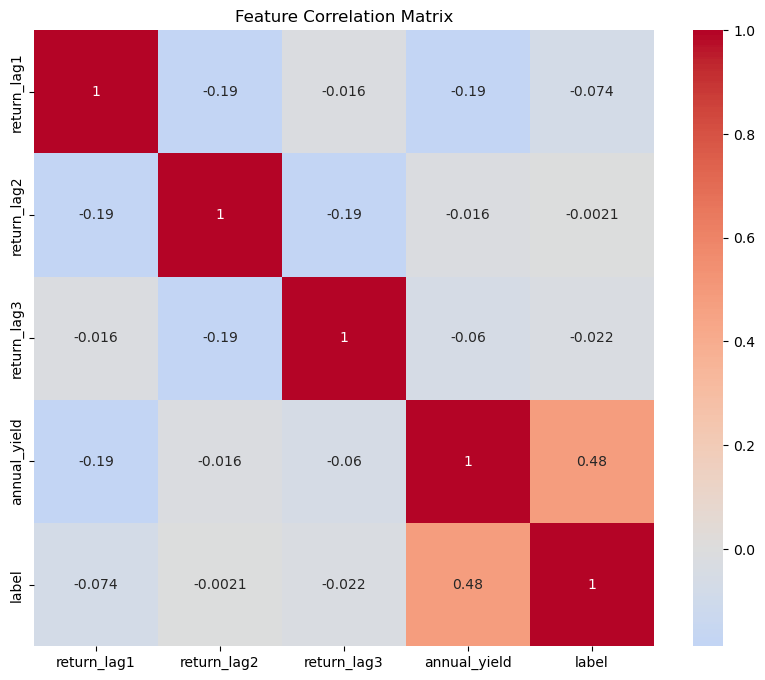

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [39]:
df.corr()

,return_lag1,return_lag2,return_lag3,annual_yield,label
return_lag1,1.000000,-0.187028,-0.016212,-0.187061,-0.074178
return_lag2,-0.187028,1.000000,-0.187139,-0.016180,-0.002064
return_lag3,-0.016212,-0.187139,1.000000,-0.059535,-0.022454
annual_yield,-0.187061,-0.016180,-0.059535,1.000000,0.482234
label,-0.074178,-0.002064,-0.022454,0.482234,1.000000


In [40]:
df.to_csv('final_data/final_tbills.csv')